# Experiment 1 — headline benchmark (LGD)

5-fold CV on the 7 LGD datasets (loss-given-default regression on [0, 1]). For each reported quantity — **R²**, **RMSE**, **training time**, and the **per-dataset rank (by R²)** — the same three views: matrix (best column left), bar, box. Then the **HPO effect on R²** and the **performance vs time** frontier.

Figures → `figures/experiment1/lgd/` (wiped on rerun).

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, method_ranking_bars, learning_curve, imbalance_curve,
    metric_boxplots, metric_bars, median_time_bars, rank_heatmap, rank_boxplots,
    hpo_improvement_bars, runtime_performance_scatter,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1/lgd')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment1\lgd


In [2]:
df      = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd')
df_both = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', hpo_mode=None)
print(f'{df["method"].nunique()} methods x {df["dataset"].nunique()} datasets')

25 methods x 7 datasets


## R²

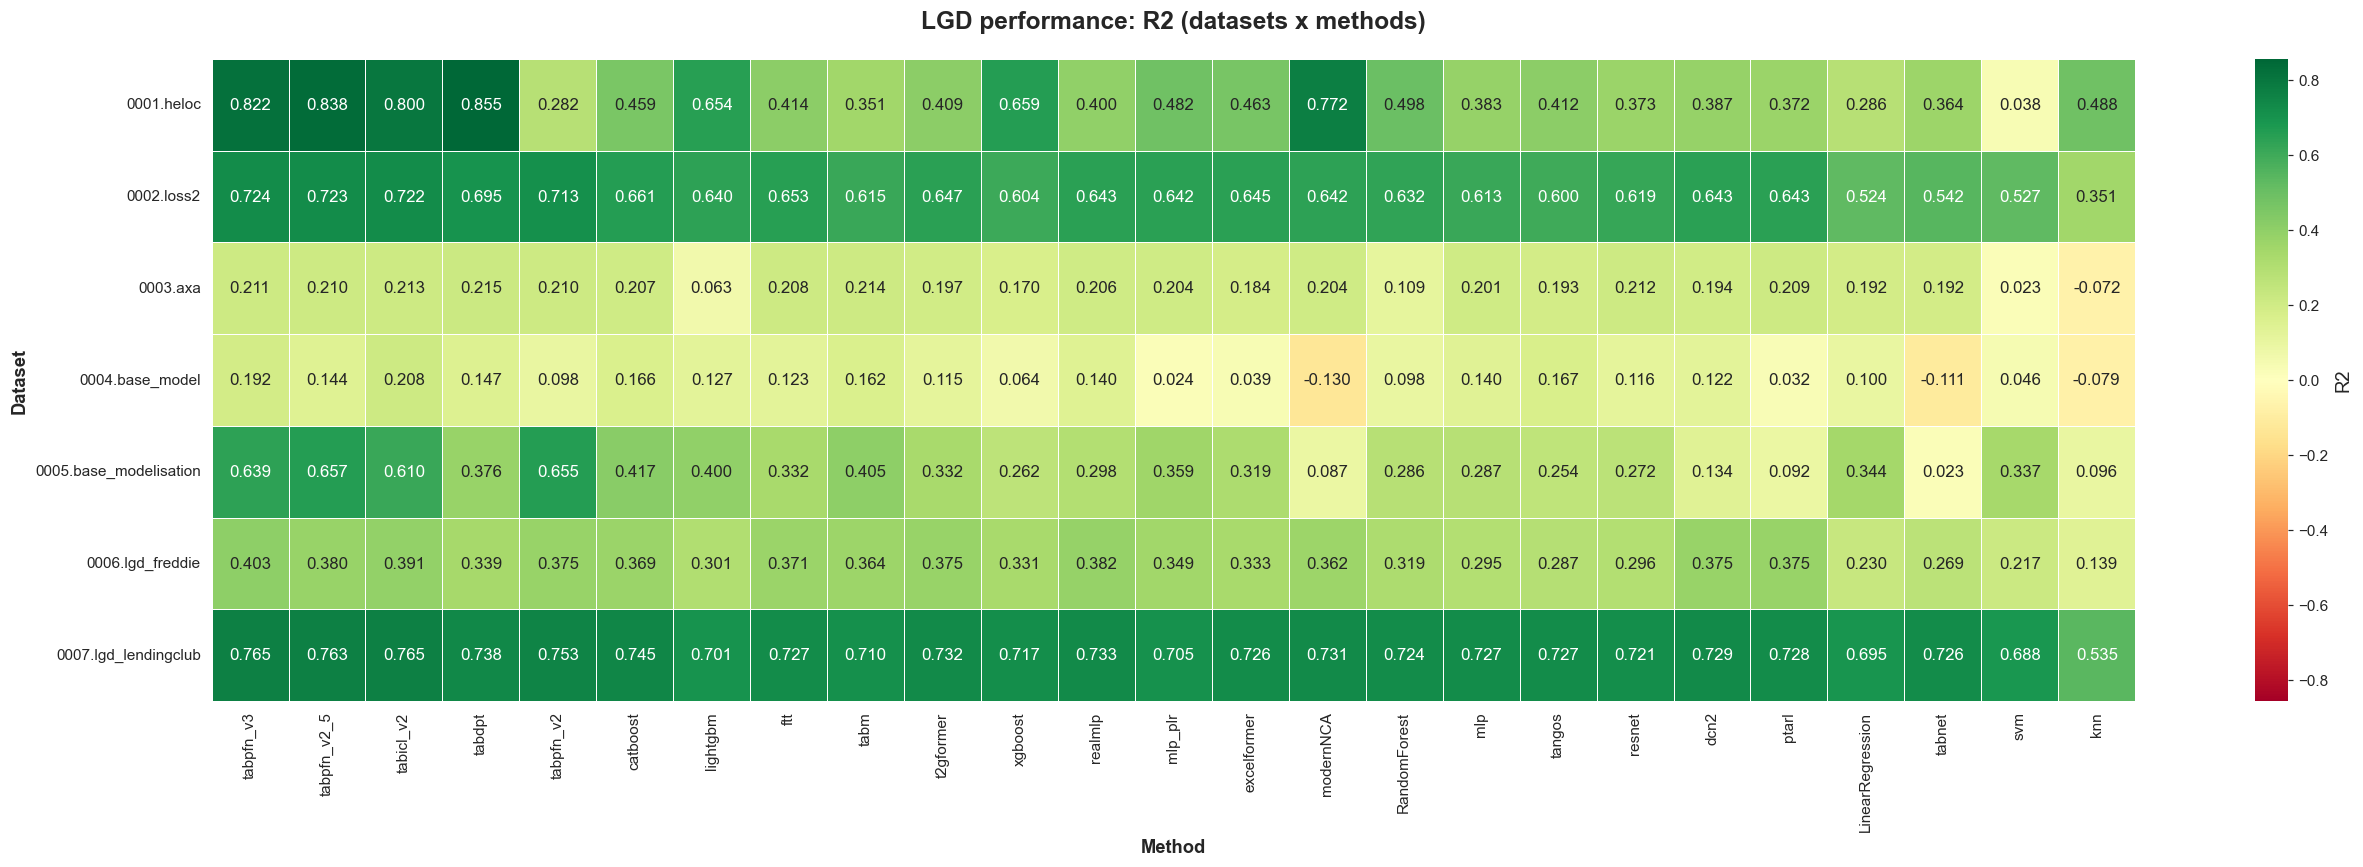

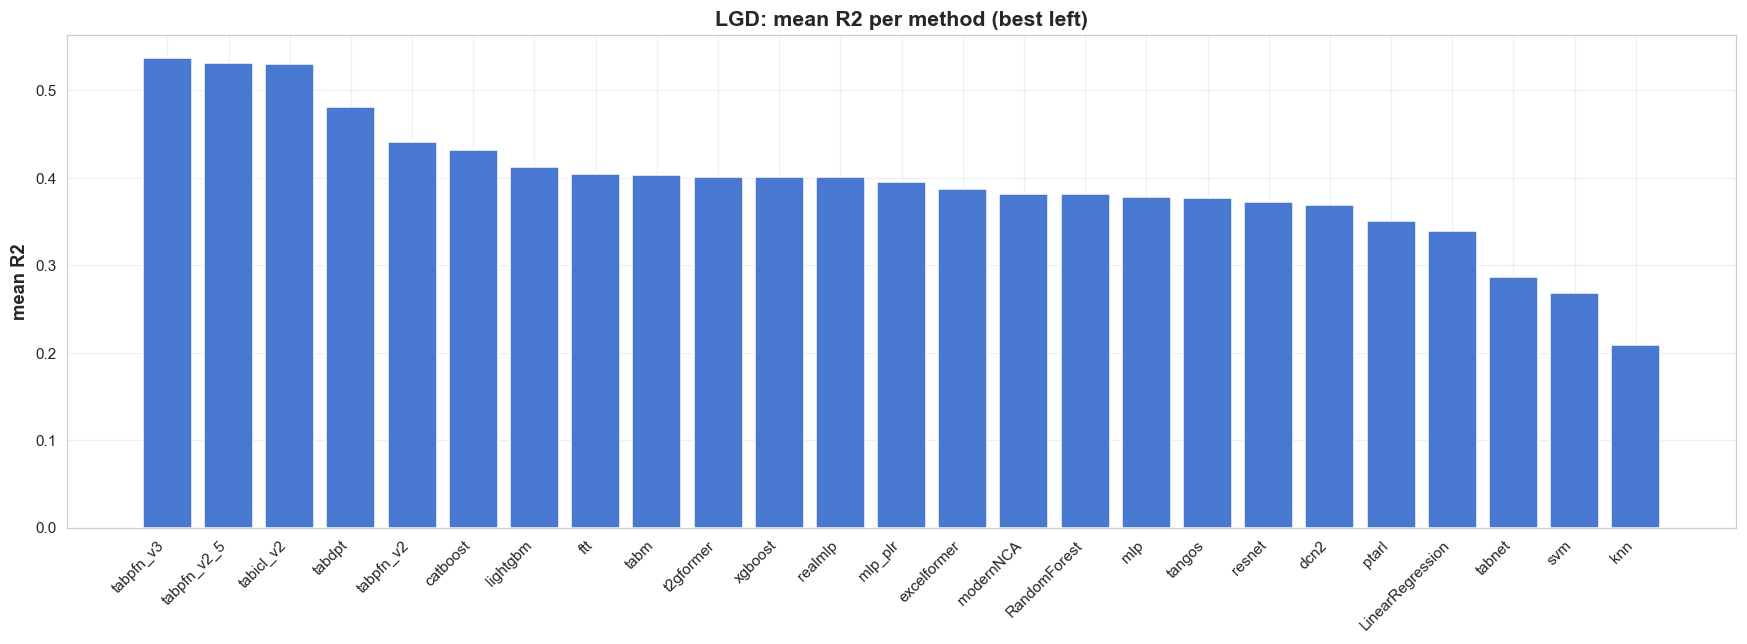

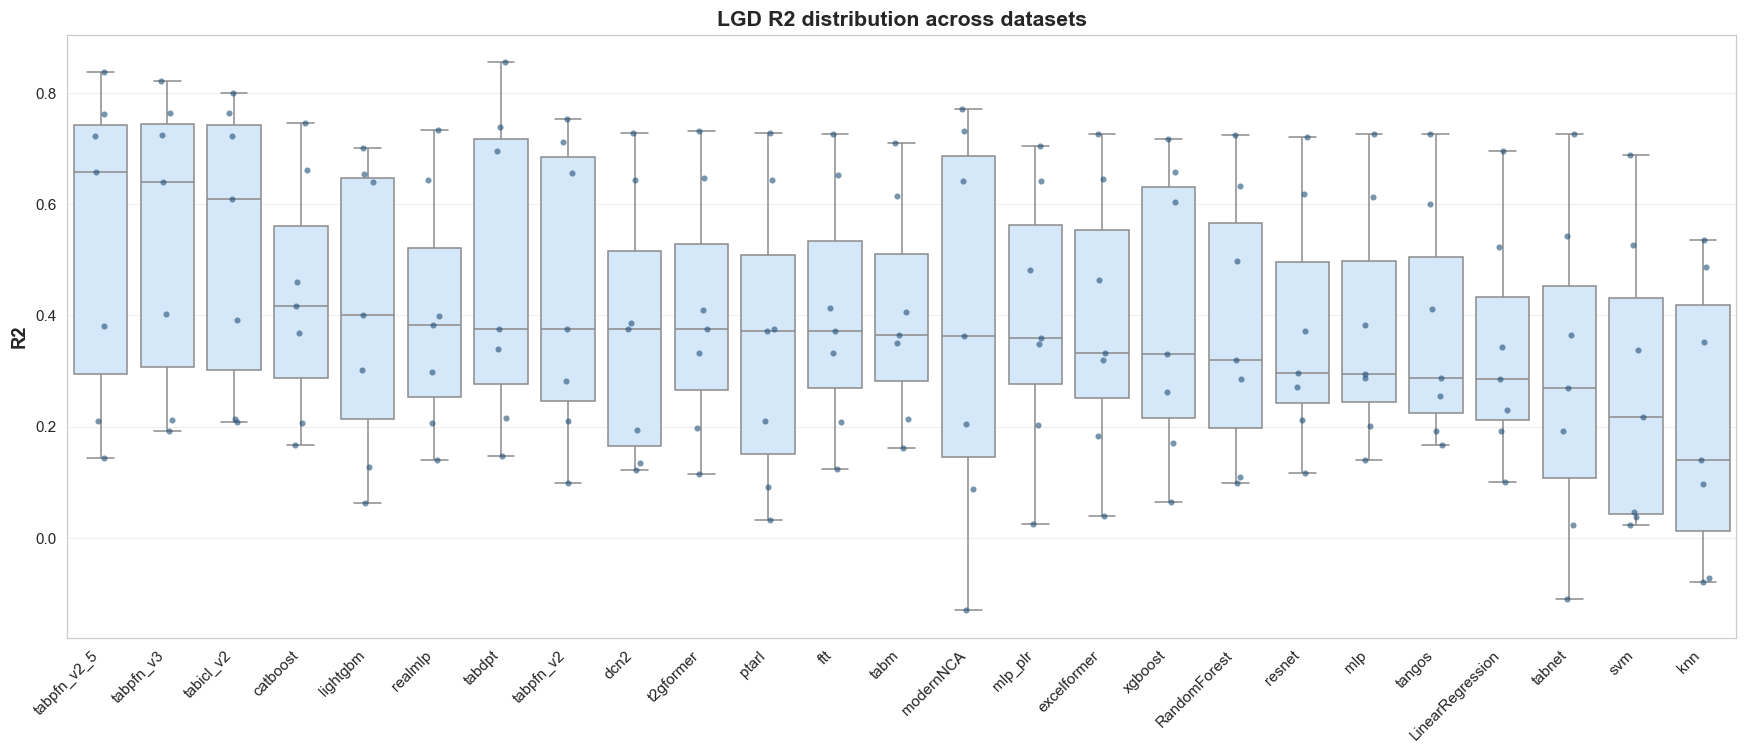

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_box_r2.pdf')

In [3]:
performance_heatmap(df, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)

## RMSE (lower is better)

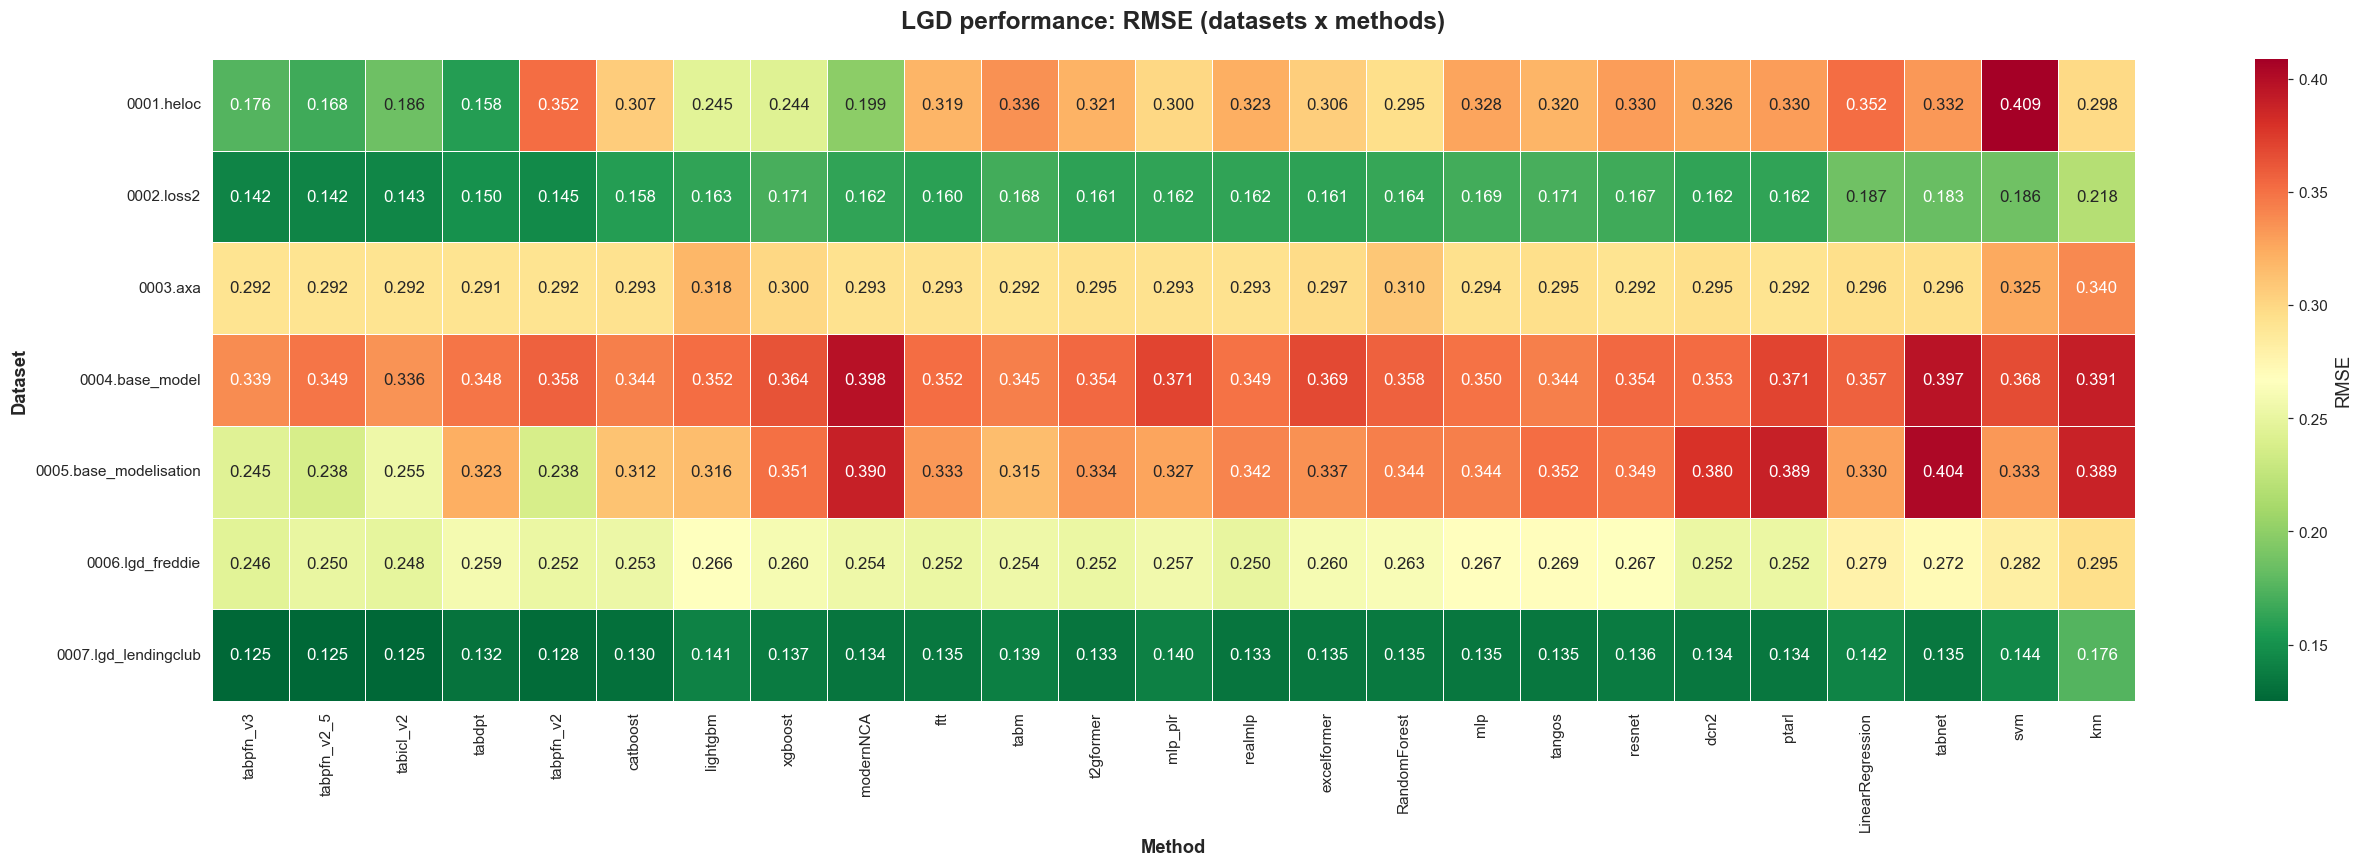

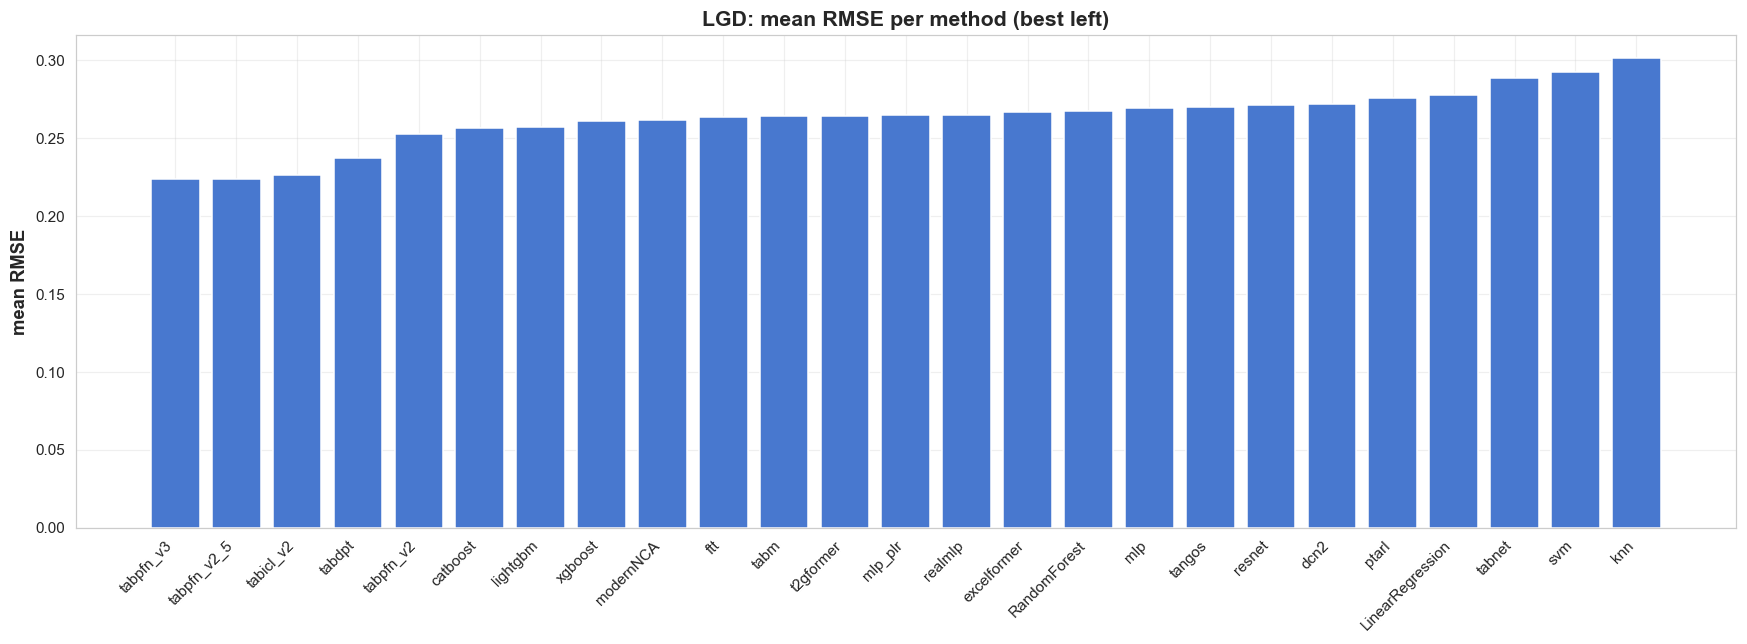

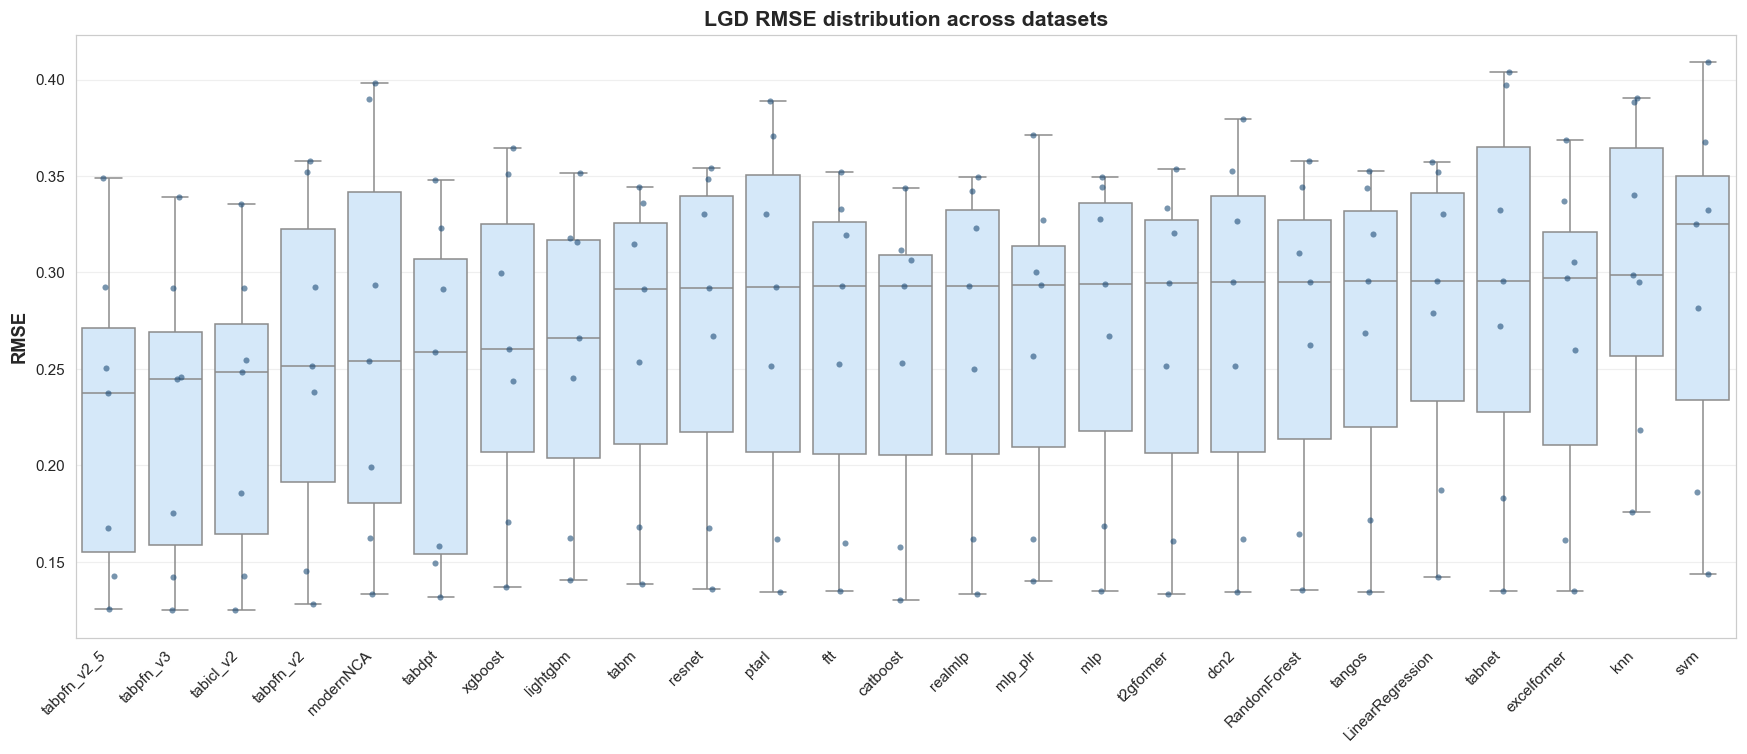

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_box_rmse.pdf')

In [4]:
performance_heatmap(df, 'RMSE', task_name='LGD', higher_is_better=False, out_dir=FIGURES_DIR)
metric_bars(df, 'RMSE', task_name='LGD', higher_is_better=False, out_dir=FIGURES_DIR)
metric_boxplots(df, 'RMSE', task_name='LGD', higher_is_better=False, out_dir=FIGURES_DIR)

## Training time (seconds per fold; lower is better)

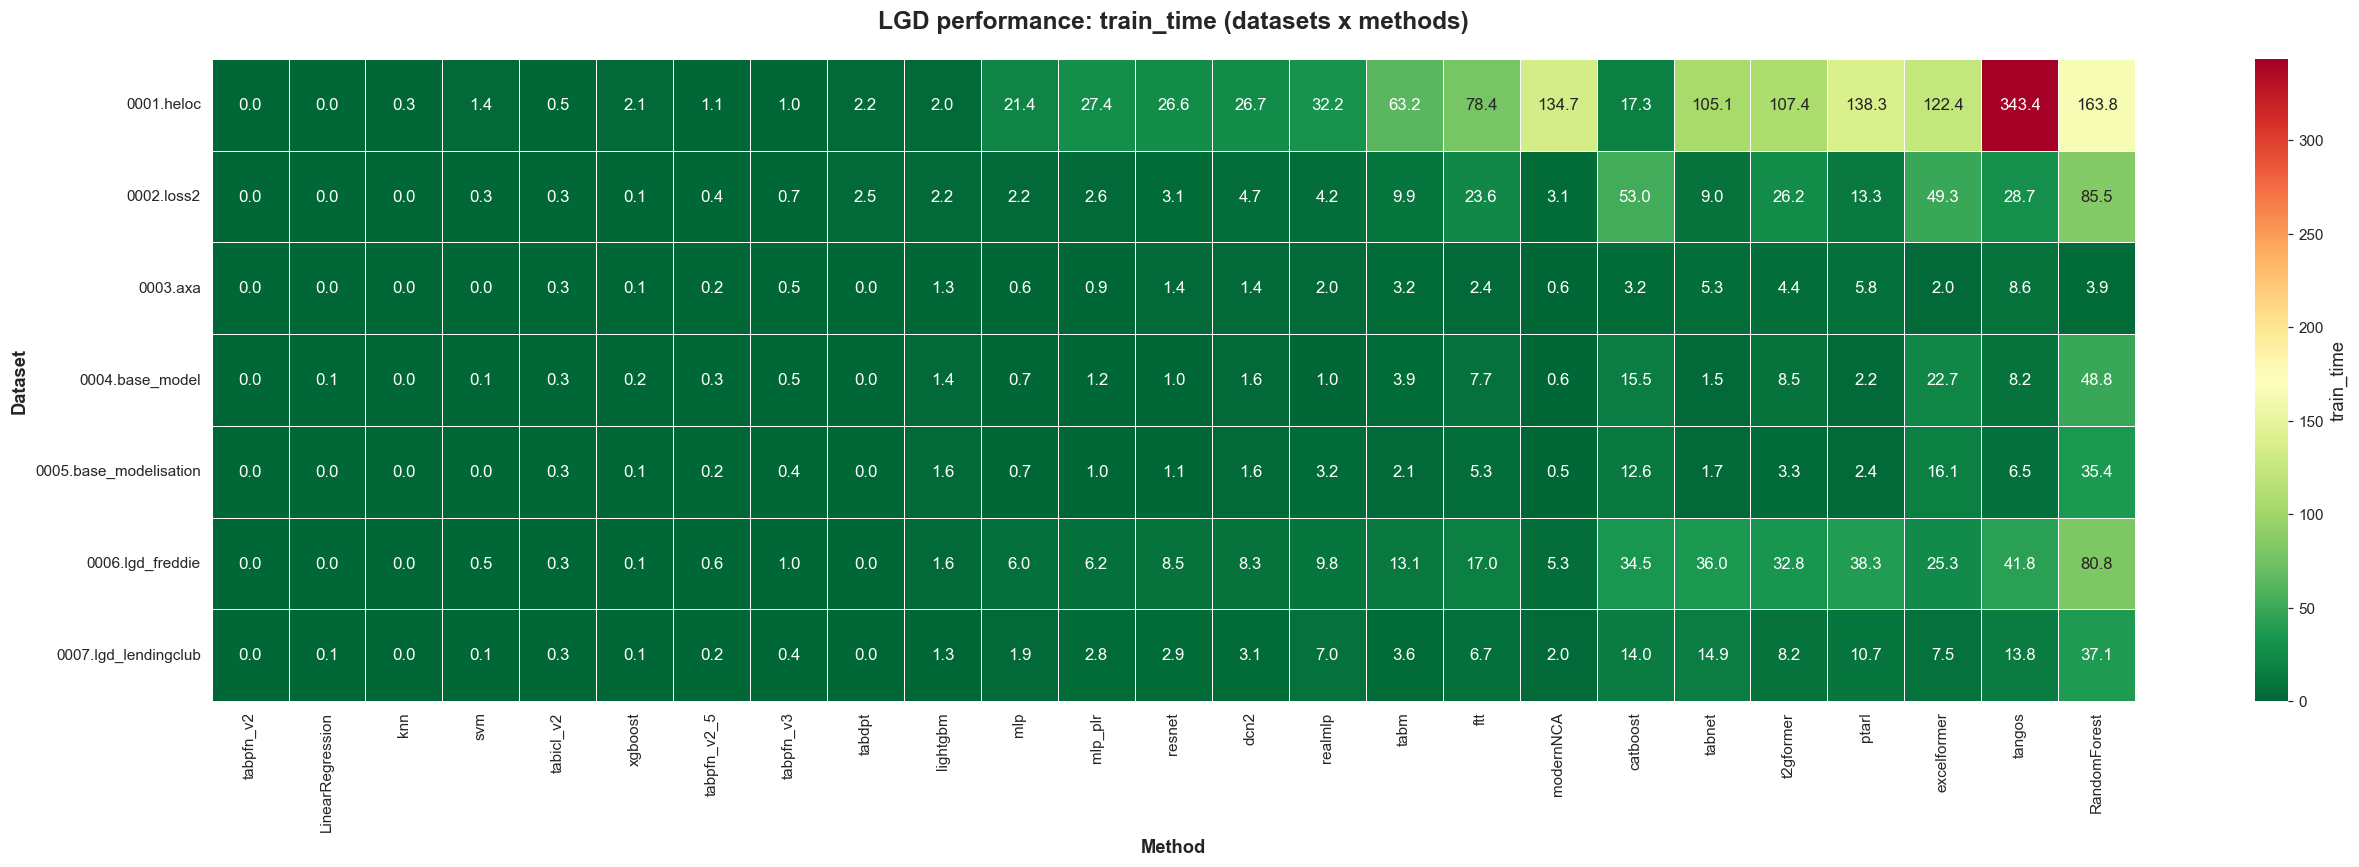

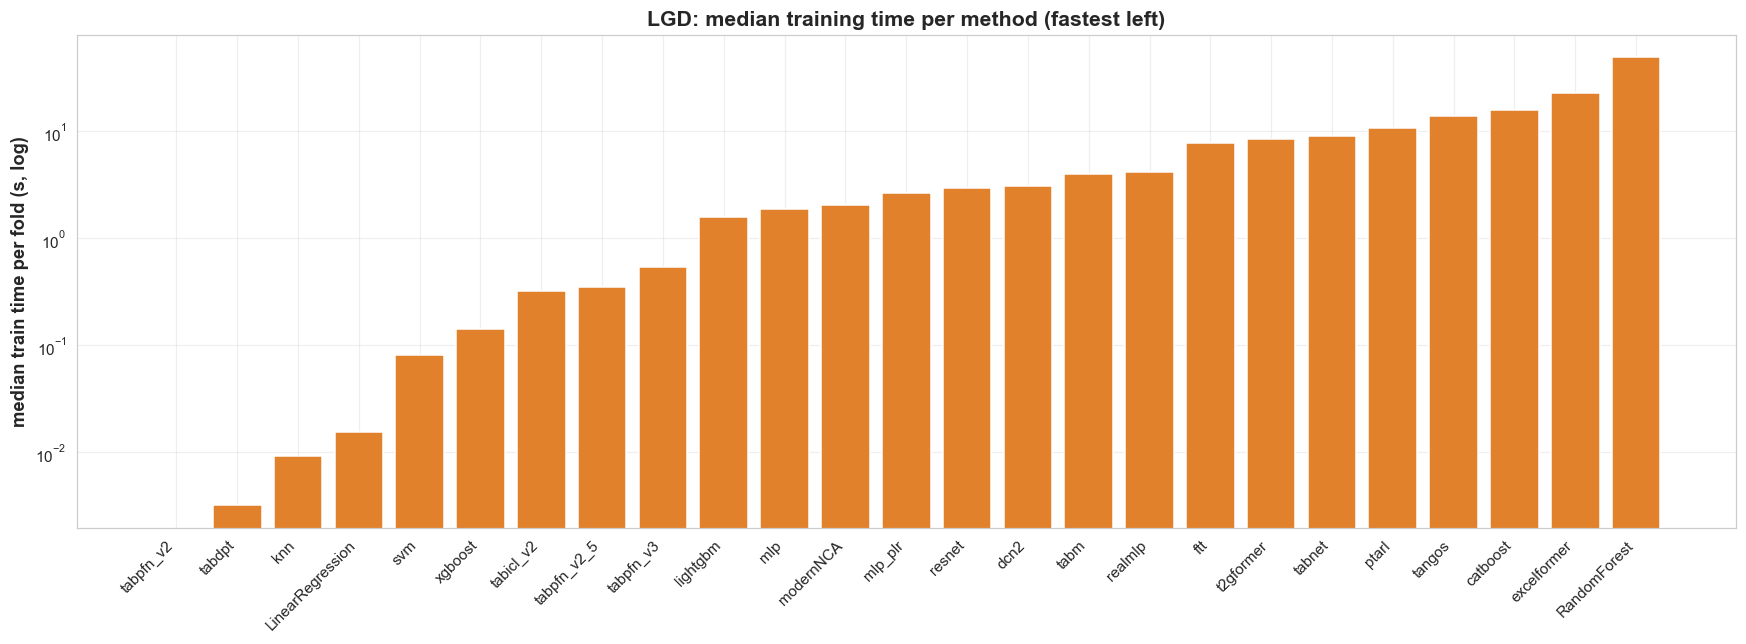

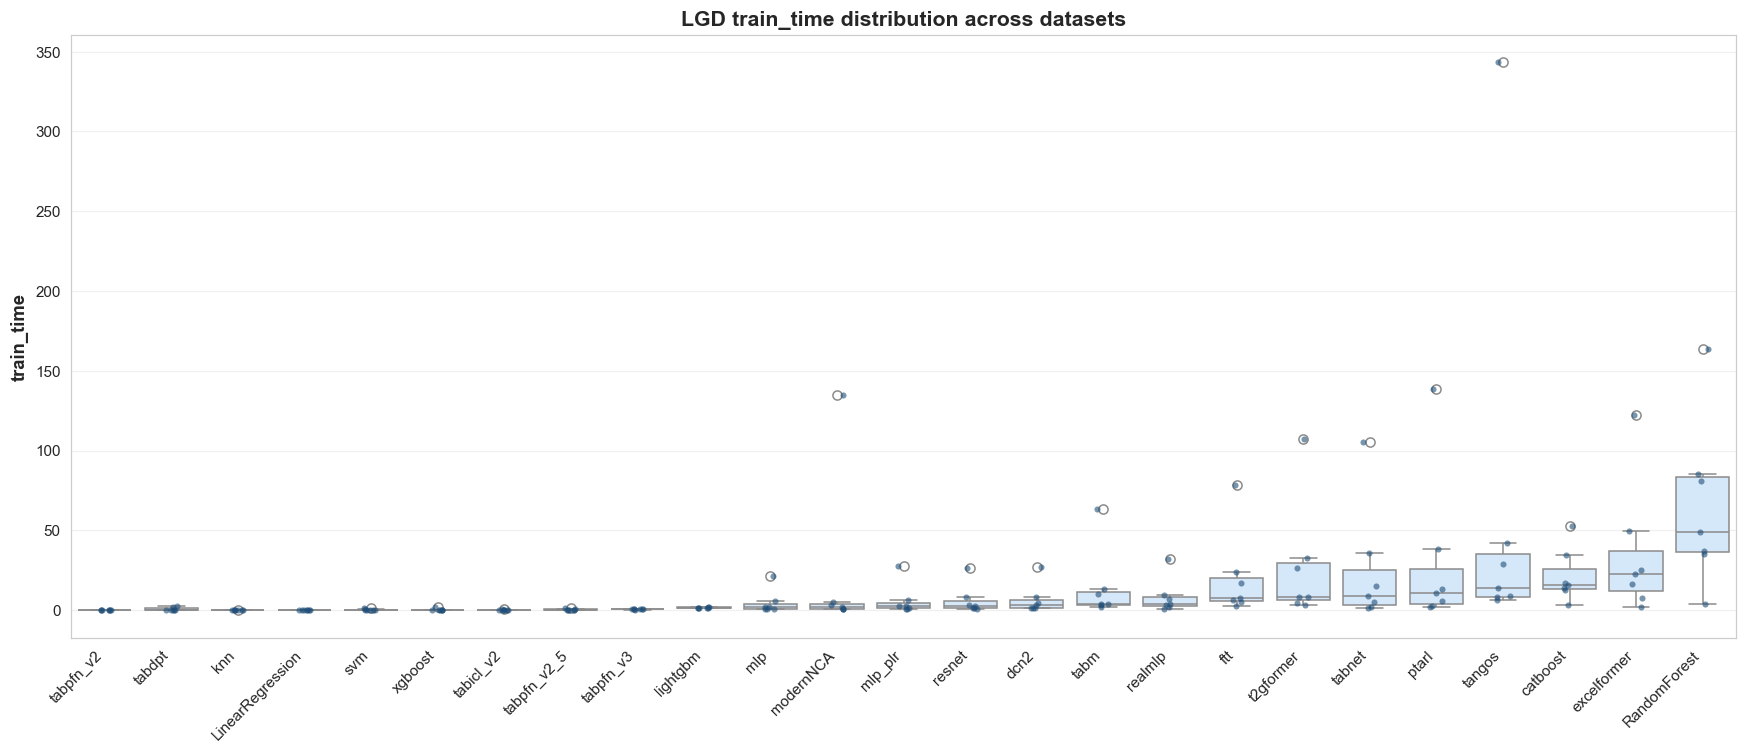

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_box_train_time.pdf')

In [5]:
performance_heatmap(df, 'train_time', task_name='LGD', higher_is_better=False, fmt='.1f', out_dir=FIGURES_DIR)
median_time_bars(df, task_name='LGD', out_dir=FIGURES_DIR)
metric_boxplots(df, 'train_time', task_name='LGD', higher_is_better=False, out_dir=FIGURES_DIR)

## Rank by R² (1 = best on that dataset)

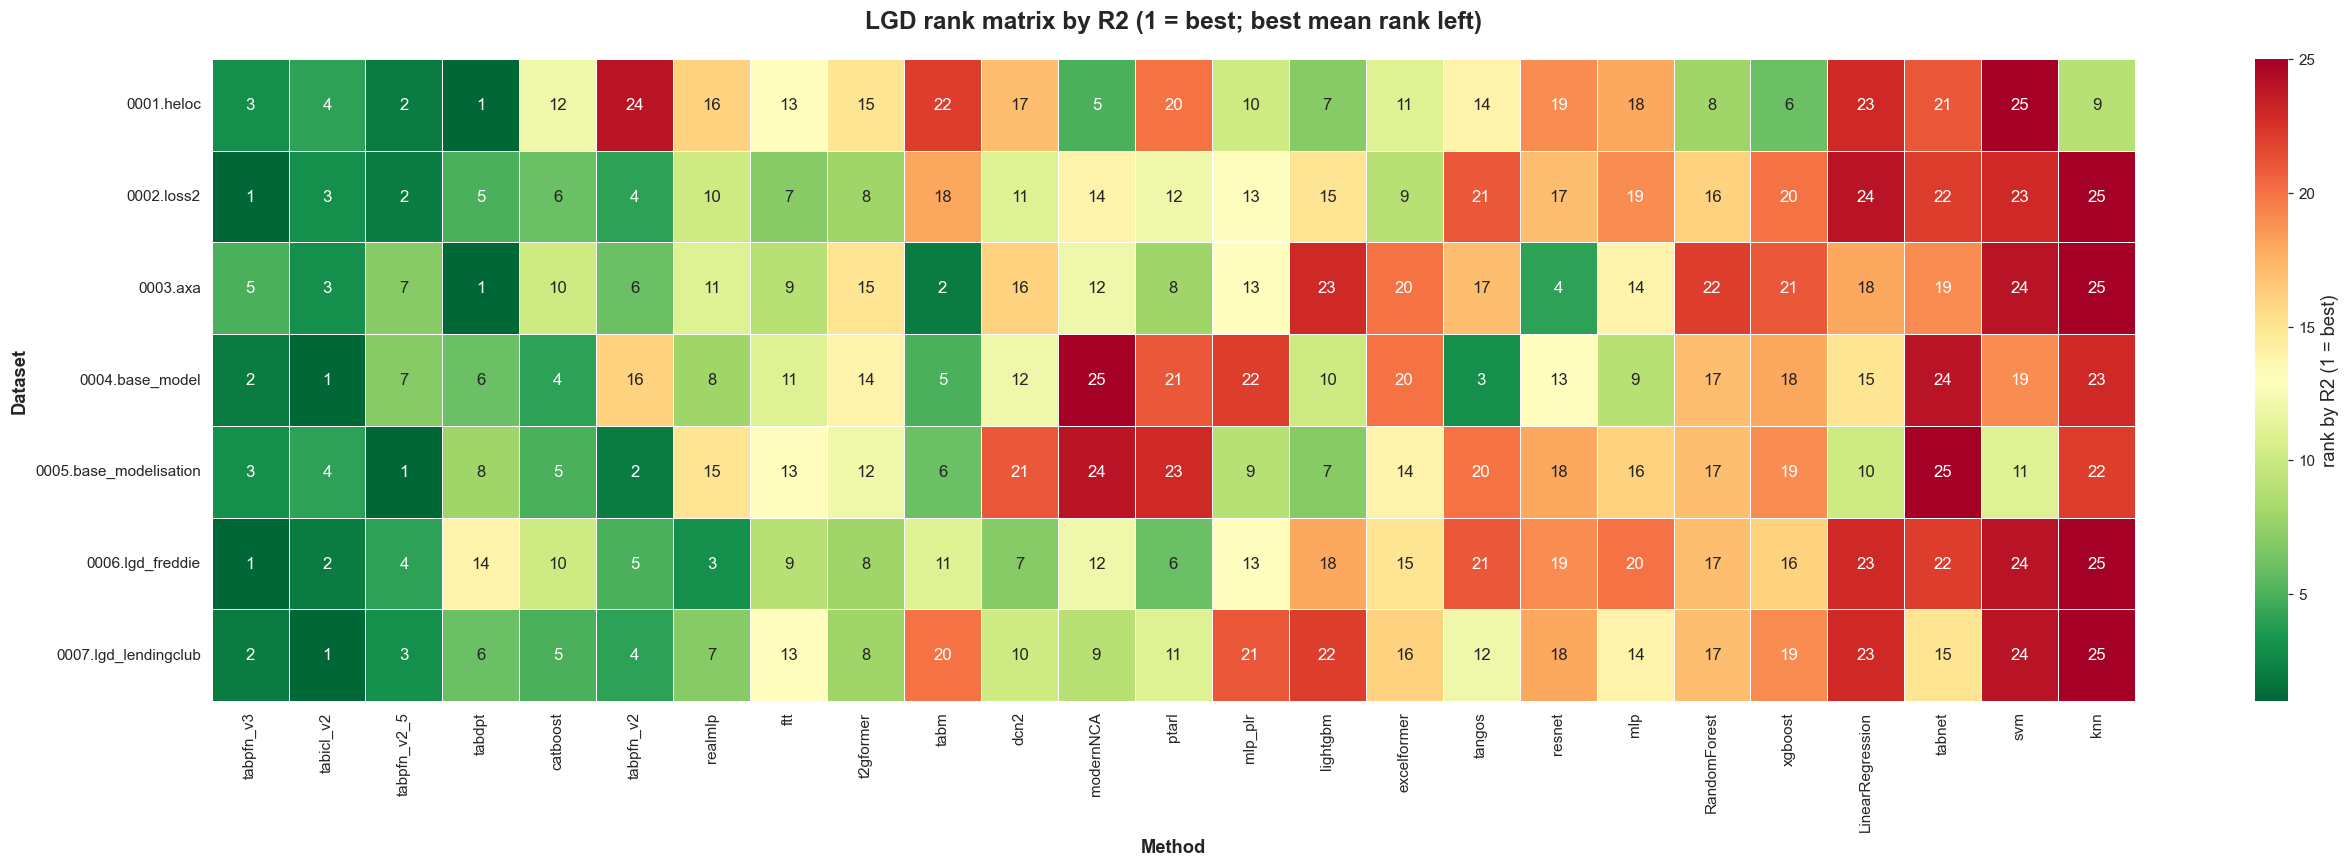

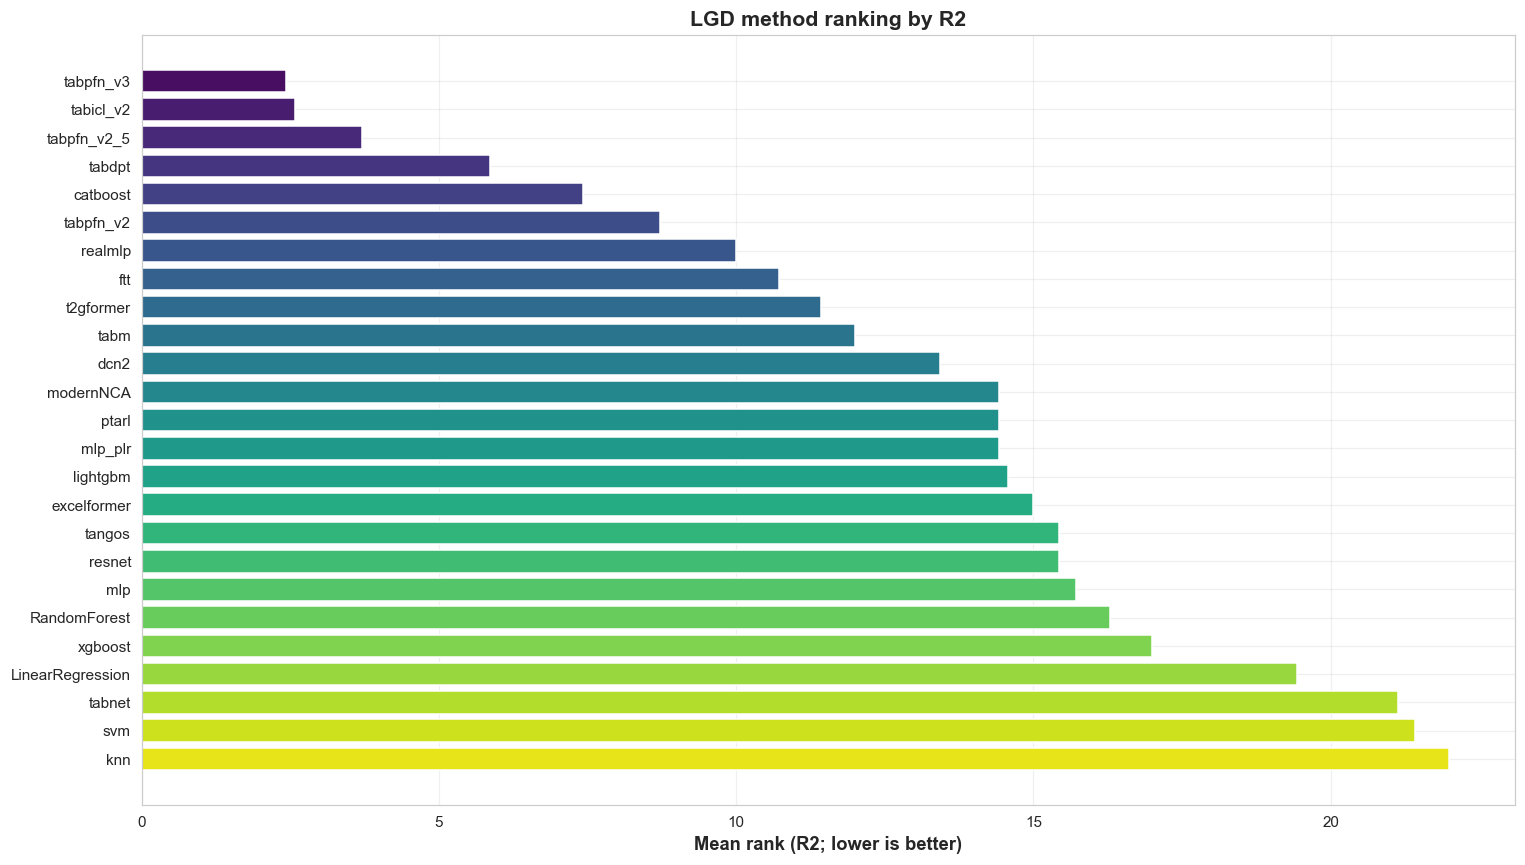

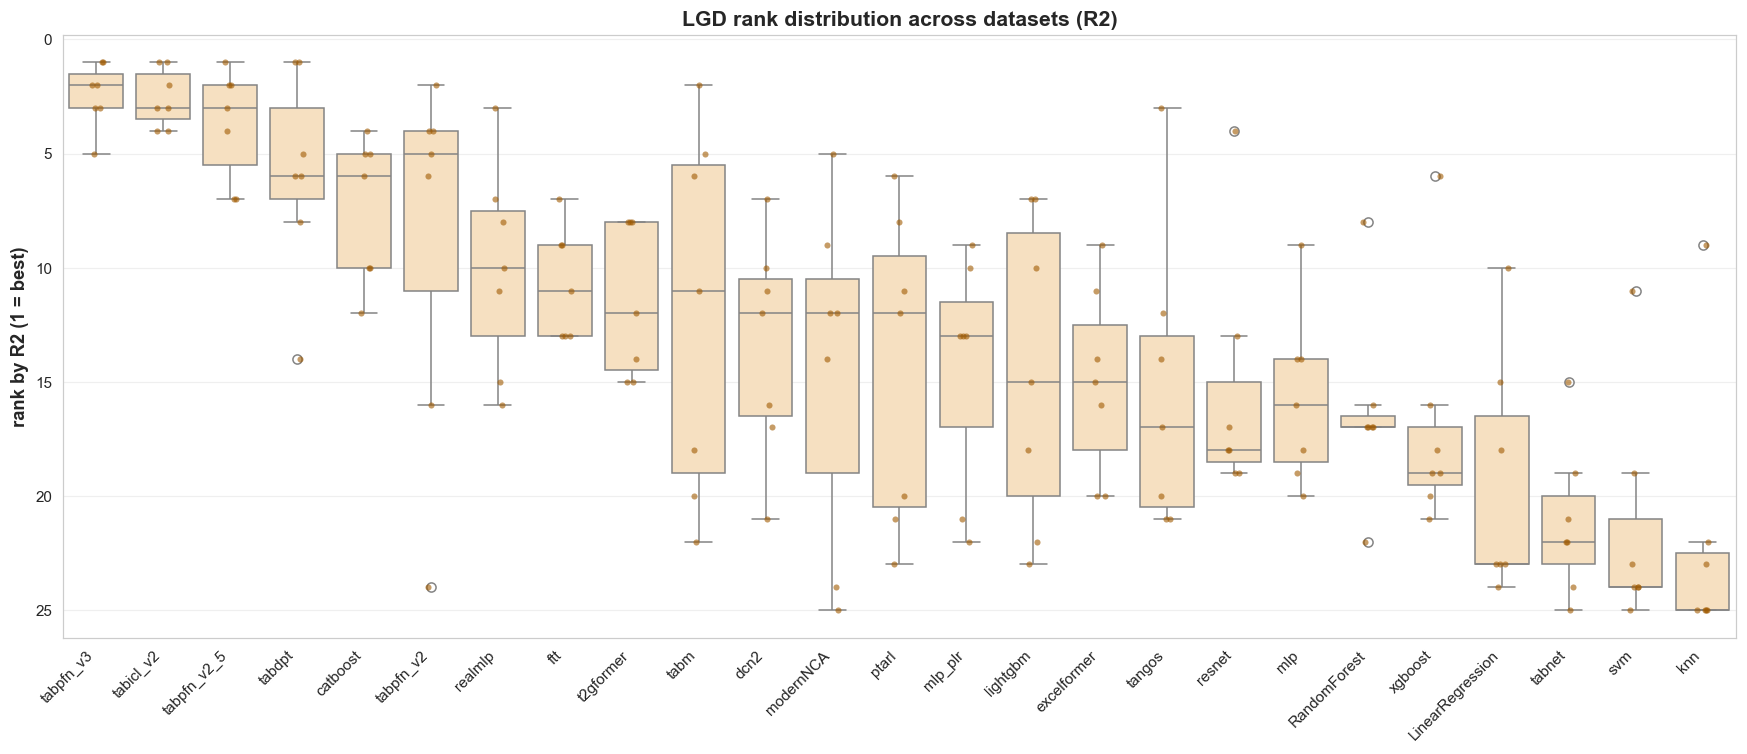

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_rank_box_r2.pdf')

In [6]:
rank_heatmap(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)
method_ranking_bars(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)
rank_boxplots(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)

## Effect of hyper-parameter tuning on R²

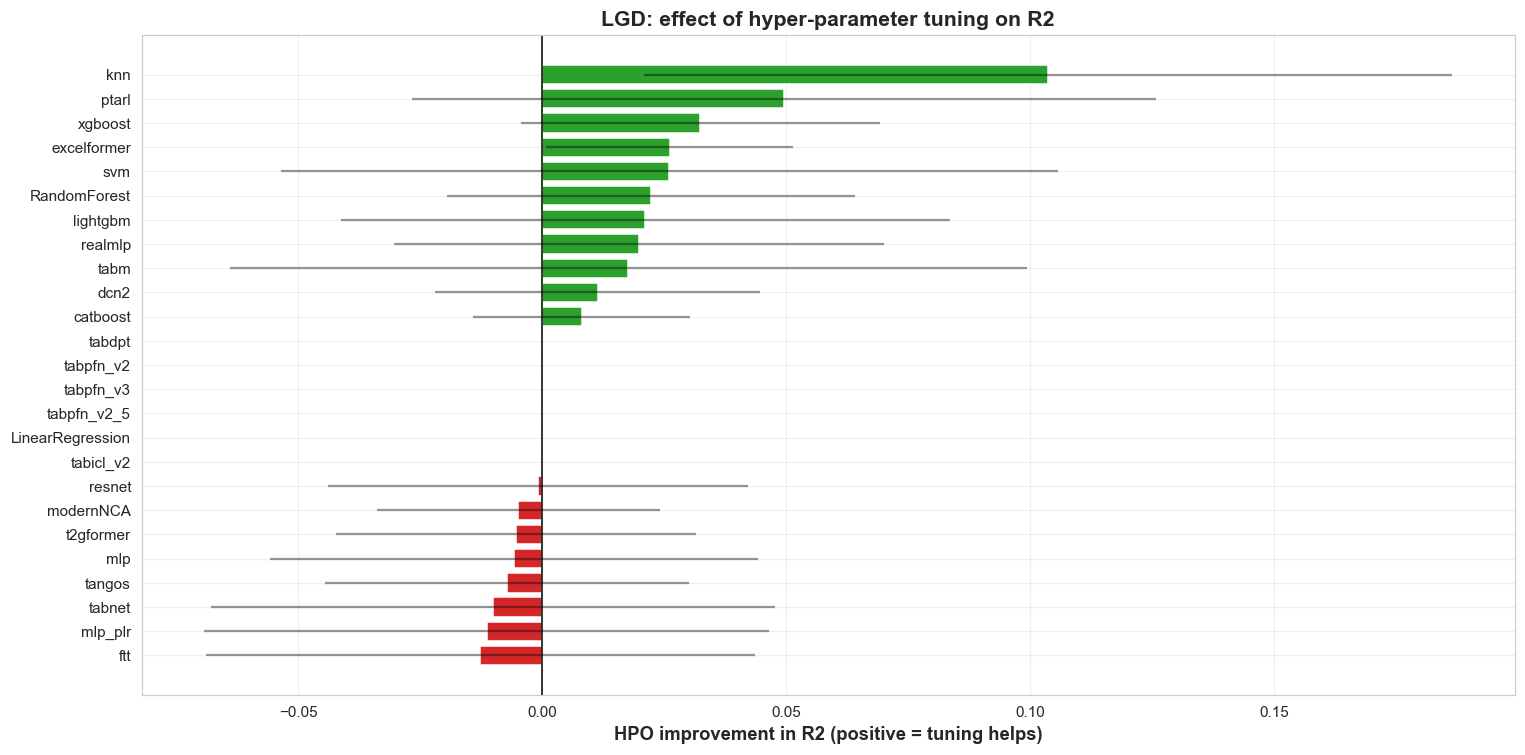

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_hpo_effect_r2.pdf')

In [7]:
hpo_improvement_bars(df_both, 'R2', task_name='LGD', out_dir=FIGURES_DIR)

## Performance vs training time

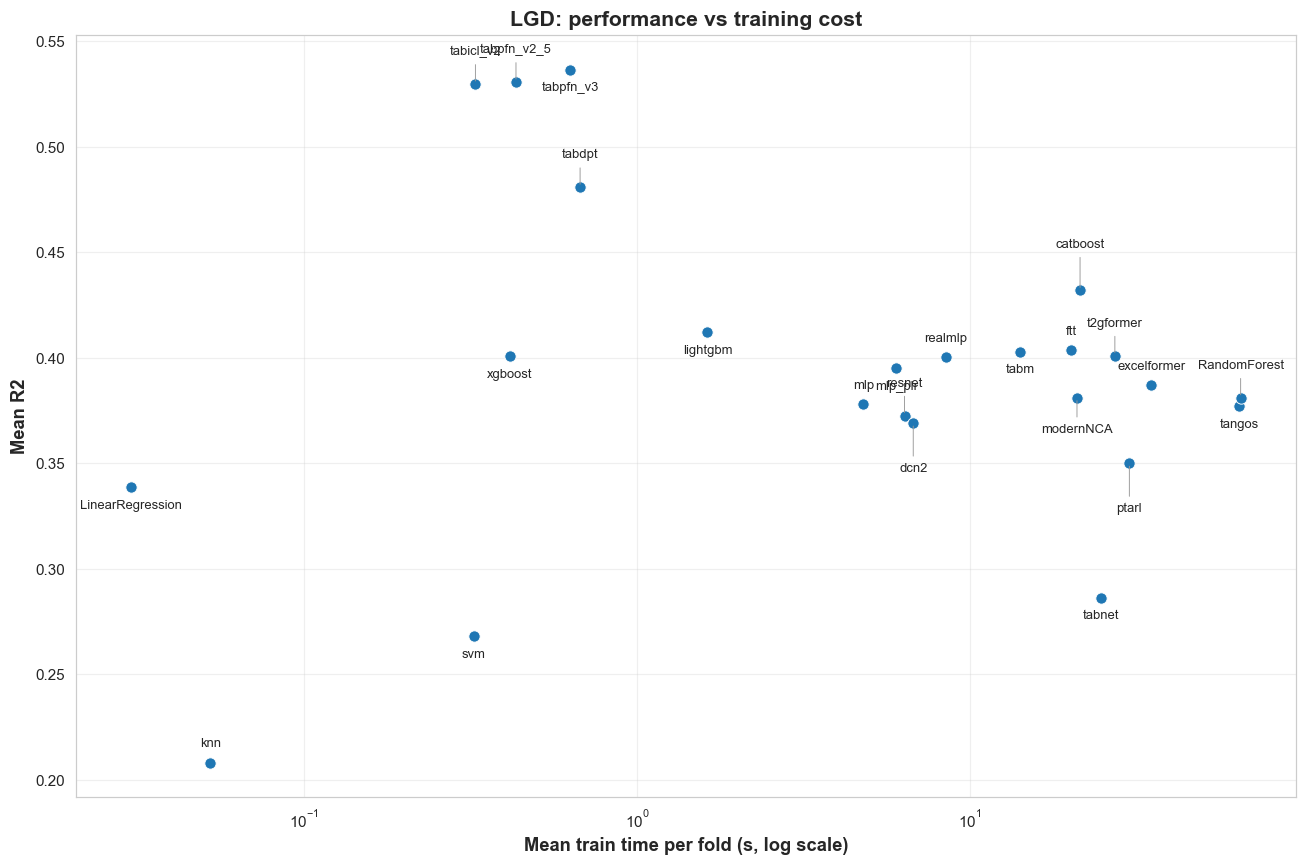

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_cost_quality_r2.pdf')

In [8]:
runtime_performance_scatter(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)